# Paper Name: Rice Leaf Disease Classification using Resource-Efficient Deep Learning Models via Response-Based Knowledge Distillation

Author Name: Maimunul Karim Jisan (https://github.com/maimunul)<br>
University ID: 201001312<br>
Department: CSE<br>
East Delta University<br>
Chittagong, Bangladesh

## Introduction to Rice Leaf Disease Classification using Knowledge Distillation
The main purpose for this project refers to a set of techniques and methodologies aimed at reducing the size of deep learning models, making them more lightweight and efficient while preserving their predictive performance. This is particularly important for deploying models on resource-constrained environments such as mobile devices, edge devices, or IOT devices.There are several technique available but we choose **Reponse-based Knowledge Distillation Technique** to reduce large model size.<br>

**Knowledge Distillation:** Training a smaller "student" model to mimic the behavior of a larger "teacher" model. The smaller model tries to reproduce the predictions and uncertainty estimates of the larger model.<br><br>

To evacute **Response-based Knowledge Distillation** using **Rice Leaf Disease Dataset** from Mendeley Data. Here dataset contain 5932 images with four different rice leaf disease. For example,

Bacterialblight Disease<br>
Blast Disease<br>
Brownspot Disease<br>
Tungro Disease<br>
The dataset contain Train (4745), Test (595) & Validation (592) Images

**Teacher** Model Accuracy is almost 99% on Test Images<br>
Getting **Studen**t model accuracy is 77% on Test Images<br>

## Introduction to Response-based Knowledge Distillation

**Response-based Knowledge Distillation (KD)** transfers knowledge from a large teacher model to a smaller student model by training the student to mimic the teacher’s **soft predictions** (probabilities). The process uses a combination of true labels and the teacher’s probabilistic outputs to improve the student’s generalization. It enhances model efficiency while maintaining performance, making it ideal for deployment on resource-constrained devices.

**Reference:**

- [Hinton et al. (2015)](https://arxiv.org/abs/1503.02531)

## This Notebook maintain Alpha Selection Distillation Network: CNN based Teacher to CNN based student

# Setup

In [20]:
import tensorflow as tf
import keras
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tabulate import tabulate
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Data Acquisation and Augmentation

In [21]:
Input_Image = 256
Channels = 3
batch_size = 32

# Data augmentation for training set
train_data = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    shear_range=0.2,
    zoom_range=0.2,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# Training set
train_set = train_data.flow_from_directory(
    r"train",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',  # Use 'categorical' for multi-class classification
    shuffle=True
)

# Validation and test sets
common_data = ImageDataGenerator(rescale=1./255)

test_set = common_data.flow_from_directory(
    r"test",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical'
)

val_set = common_data.flow_from_directory(
    r"val",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical'
)
# Input shape
input_shape = (Input_Image, Input_Image, Channels)

Found 4745 images belonging to 4 classes.
Found 595 images belonging to 4 classes.
Found 592 images belonging to 4 classes.


<a ></a>
# <p style="background-color:skyblue; font-family:newtimeroman; font-size:150%; text-align:center; border-radius: 15px 50px;"> Knowledge Distillation 💎</p>


# Loading Teacher Model

19/19 [==============================] - 2s 77ms/step - loss: 0.0710 - accuracy: 0.9916
Model: "teacher"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 127, 127, 16)      0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 125, 125, 32)      4640      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 62, 62, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 60, 60, 64)        18496     
                                     

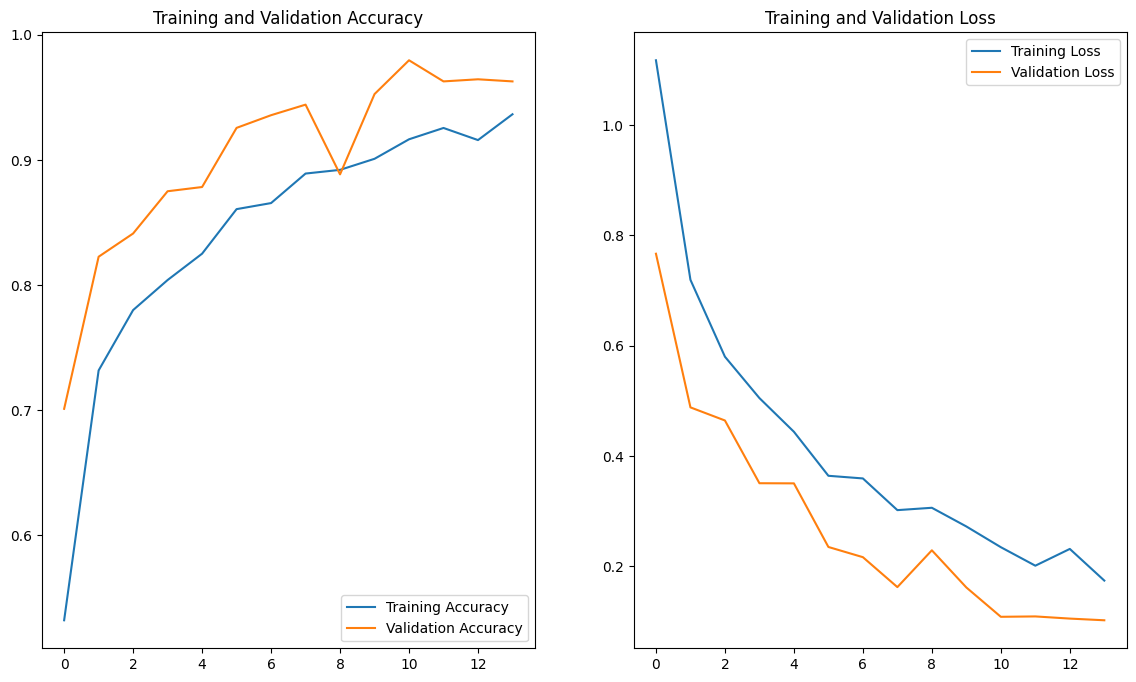

19/19 [==============================] - 1s 52ms/step - loss: 0.0710 - accuracy: 0.9916
Test Acc: 0.9915966391563416
19/19 [==============================] - 1s 48ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       159
           1       1.00      0.97      0.98       144
           2       0.99      1.00      0.99       160
           3       1.00      1.00      1.00       132

    accuracy                           0.99       595
   macro avg       0.99      0.99      0.99       595
weighted avg       0.99      0.99      0.99       595



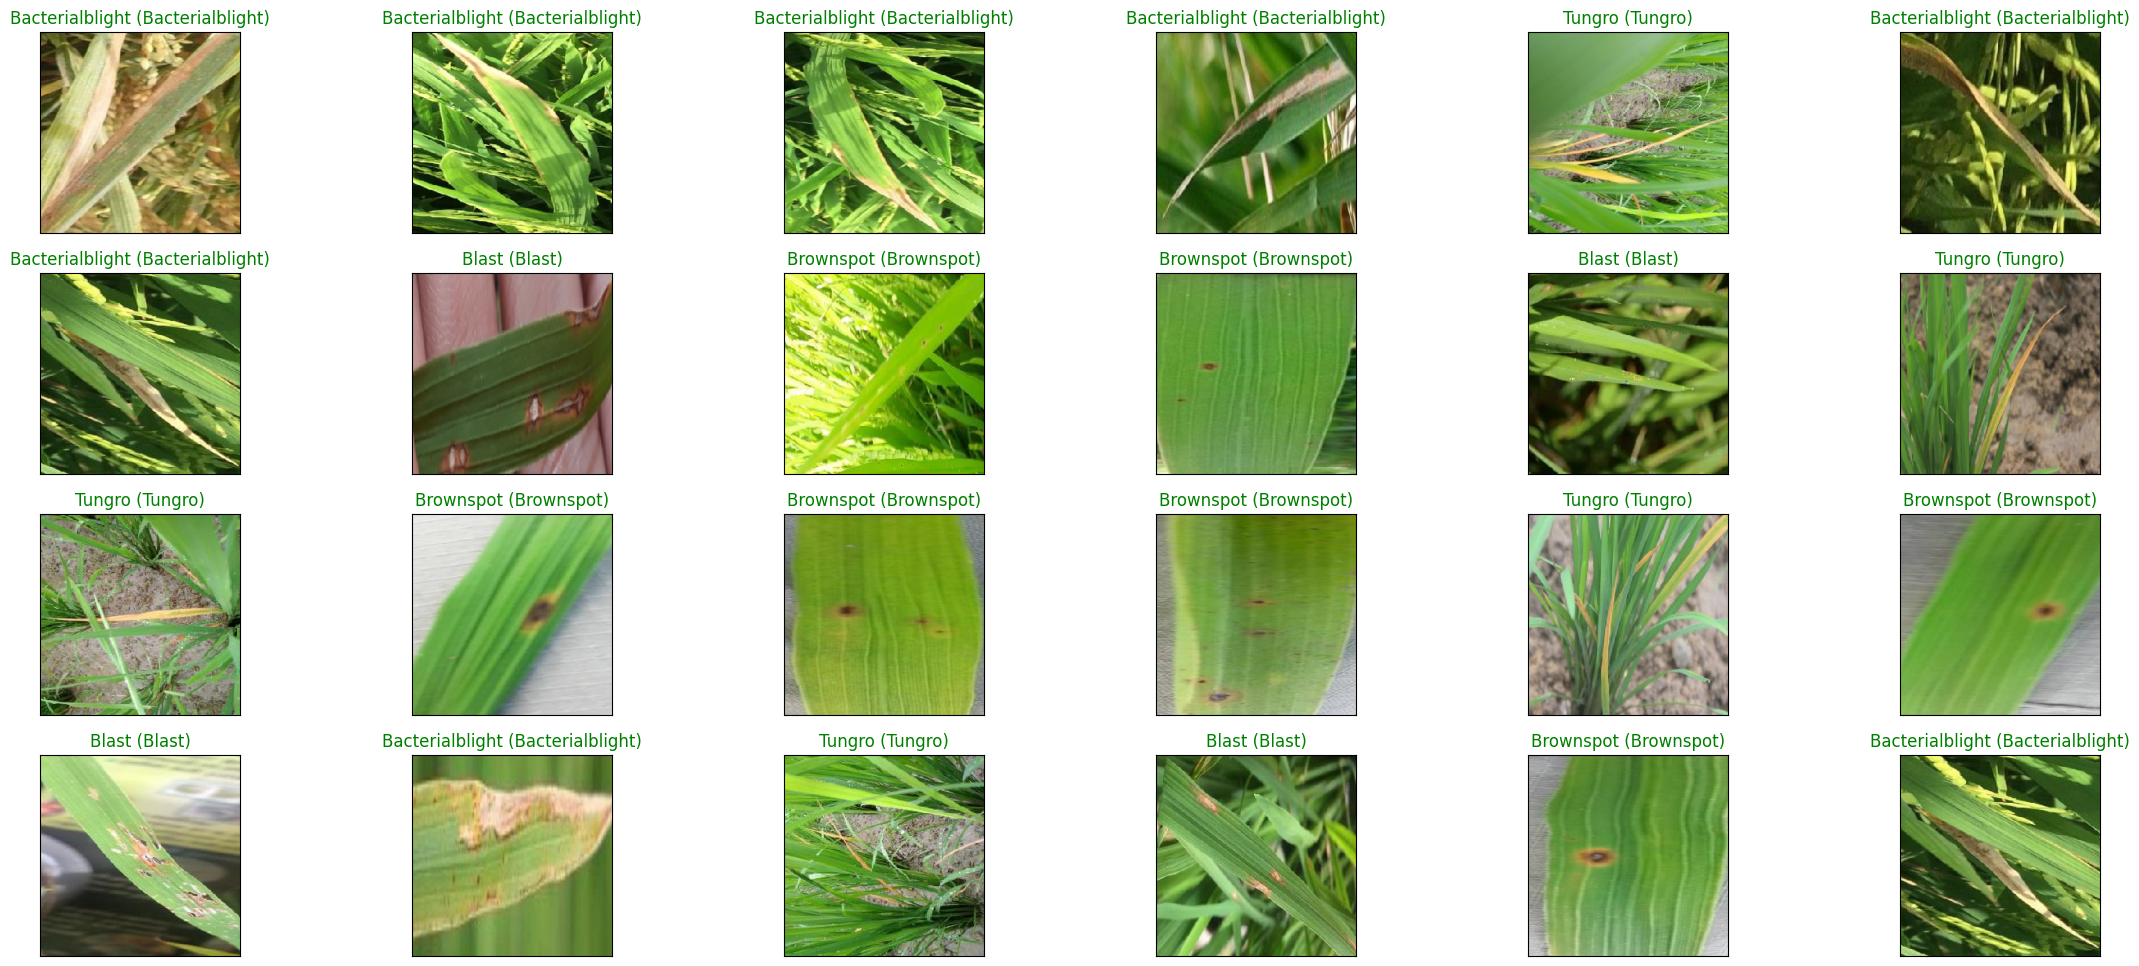

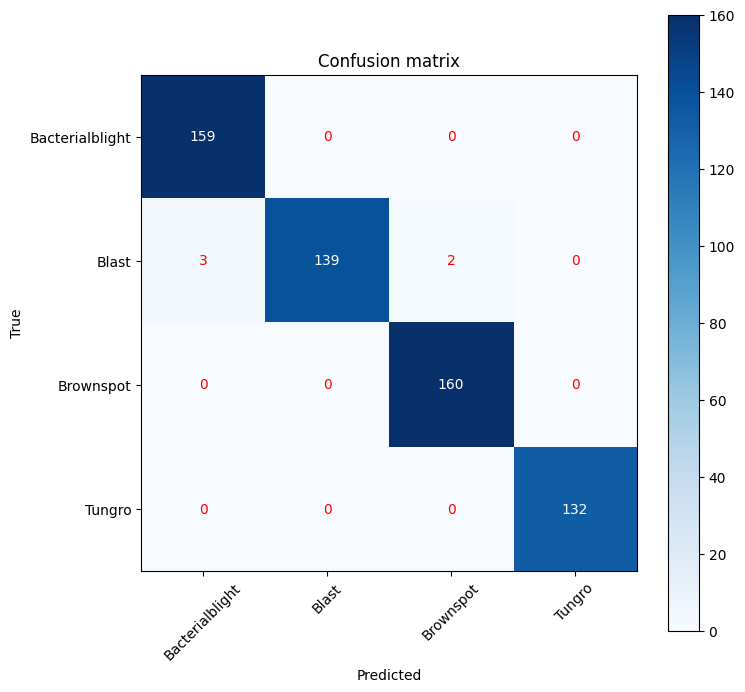

In [22]:
import json
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the model
teacher = tf.keras.models.load_model(r"AlphaSelection\BestTeacher.h5")

# Evaluate and summarize the model
teacher.evaluate(test_set)
teacher.summary()

# Load the training history (JSON format)
history_path = r'AlphaSelection\Best_Teacher_history.json'  # JSON file path
with open(history_path, 'r') as history_file:
    loaded_history = json.load(history_file)

# Access metrics from the loaded history
acc = loaded_history['accuracy']
val_acc = loaded_history['val_accuracy']
loss = loaded_history['loss']
val_loss = loaded_history['val_loss']

# Plot the training history
epochs = len(acc)
plt.figure(figsize=(14, 8))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def extract_data(generator):
    data_list = []
    labels_list = []
    for _ in range(generator.__len__()):
        data, labels = generator.next()
        data_list.append(data)
        labels_list.append(labels)
    x = np.vstack(data_list)
    y = np.vstack(labels_list)
    return x, y

x_train, y_train = extract_data(train_set)
x_test, y_test = extract_data(test_set)

loss = teacher.evaluate(x_test,y_test)
print("Test Acc: " + str(loss[1]))
preds = teacher.predict(x_test)
y_pred = np.argmax(preds , axis = 1 )
label_dict = {0 : 'Bacterialblight', 1 : 'Blast', 2 : 'Brownspot', 3 : 'Tungro'}

figure = plt.figure(figsize=(28, 12))
for i, index in enumerate(np.random.choice(x_test.shape[0], size=24)):
    ax = figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_test[index]))
    predict_index = label_dict[(y_pred[index])]
    true_index = label_dict[np.argmax(y_test,axis=1)[index]]

    ax.set_title("{} ({})".format((predict_index),
                                  (true_index)),
                                  color=("green" if predict_index == true_index else "red"))
# Generate classification report
y_true = np.argmax(y_test, axis=1)
report = classification_report(y_true, y_pred)
print(report)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()

classes = list(label_dict.values())
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Print the confusion matrix values on each cell
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='red' if i != j else 'white')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



# Loading Student Model

19/19 [==============================] - 1s 65ms/step - loss: 0.5833 - accuracy: 0.7782
Model: "student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 127, 127, 16)      0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 125, 125, 16)      2320      
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 62, 62, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 60, 60, 16)        2320      
                                     

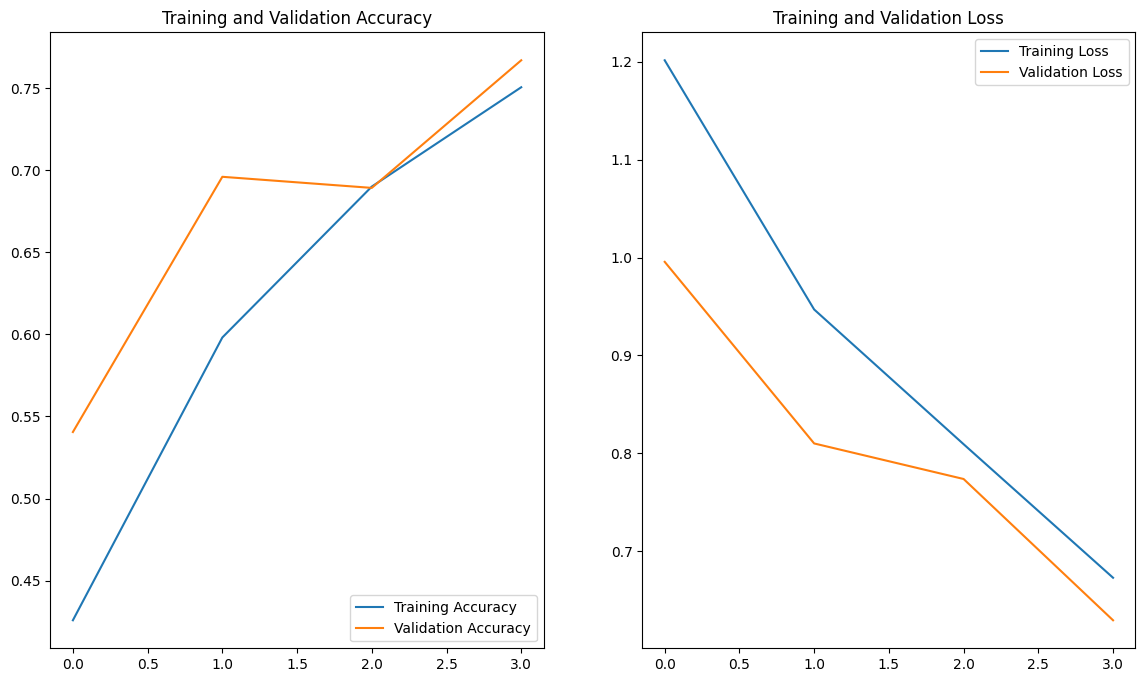

19/19 [==============================] - 1s 35ms/step - loss: 0.5833 - accuracy: 0.7782
Test Acc: 0.778151273727417
19/19 [==============================] - 1s 34ms/step
              precision    recall  f1-score   support

           0       0.88      0.68      0.77       159
           1       0.72      0.66      0.69       144
           2       0.91      0.82      0.87       160
           3       0.66      0.97      0.78       132

    accuracy                           0.78       595
   macro avg       0.79      0.78      0.78       595
weighted avg       0.80      0.78      0.78       595



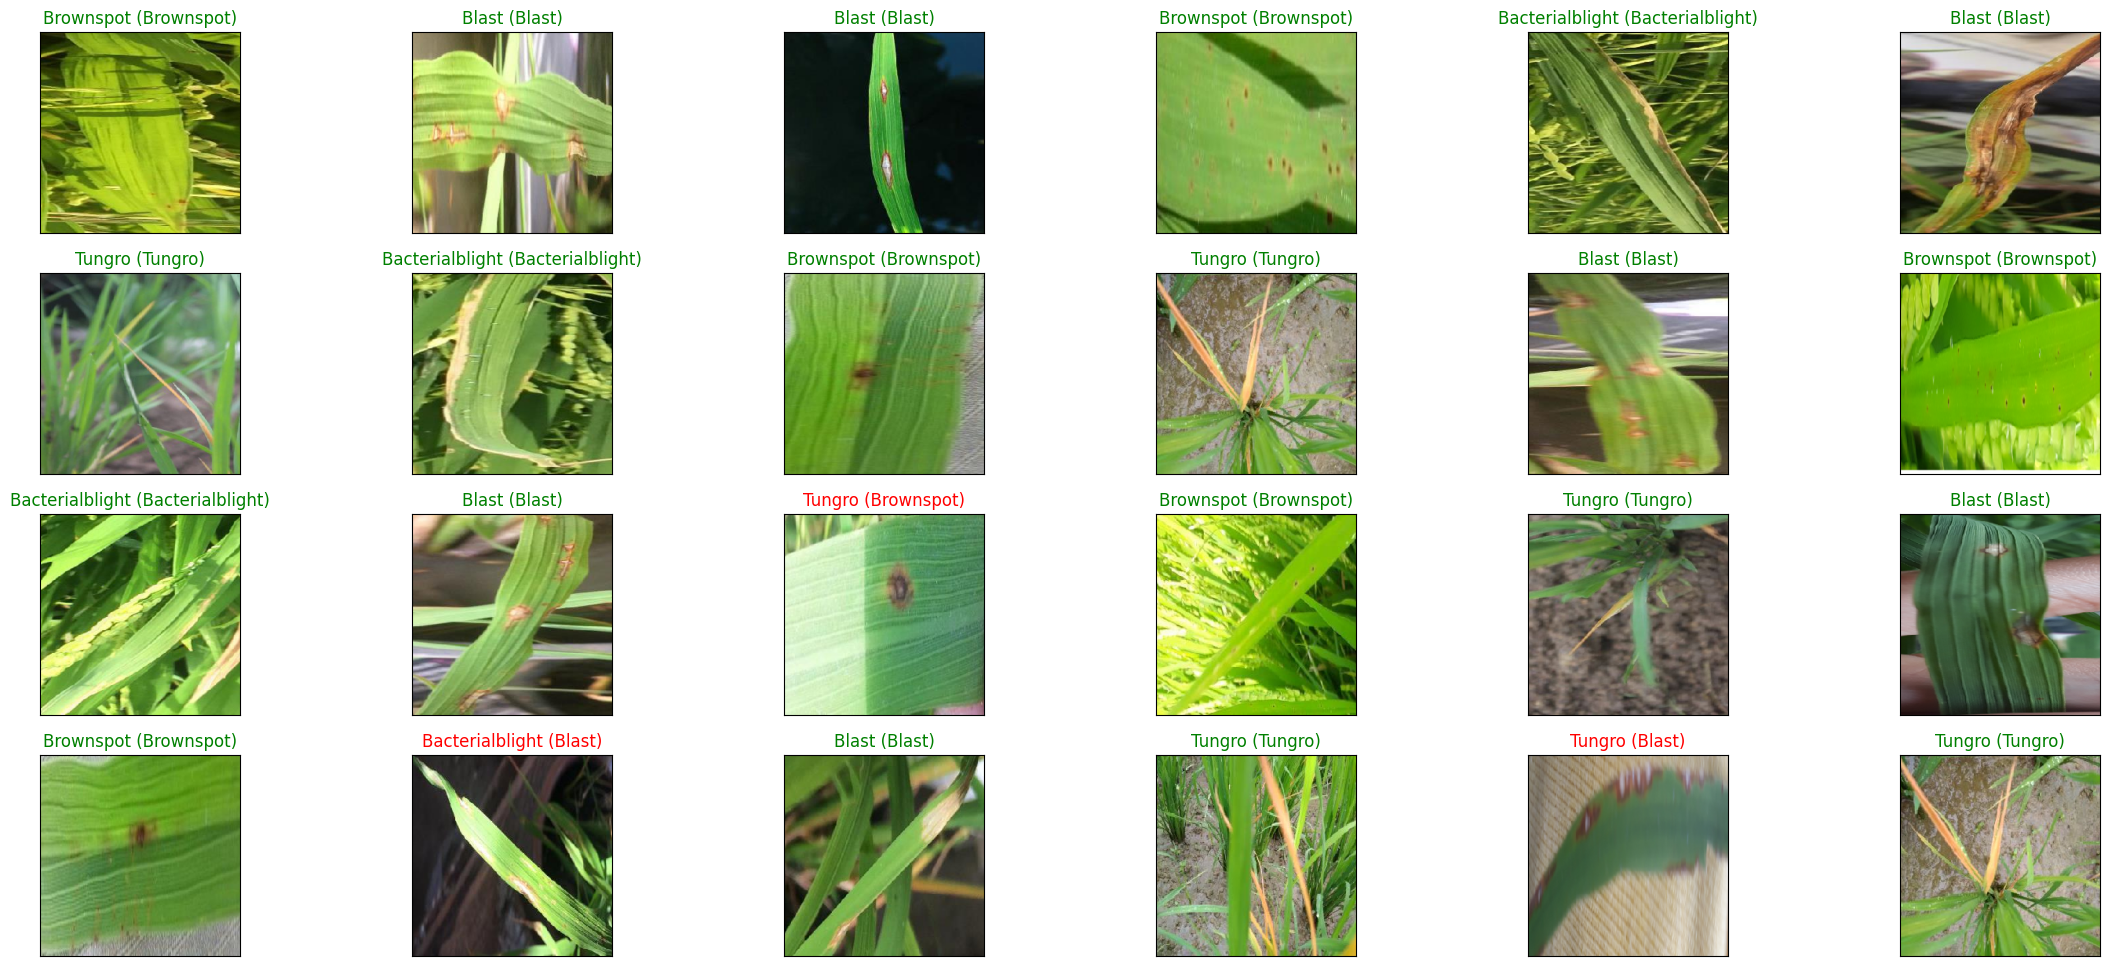

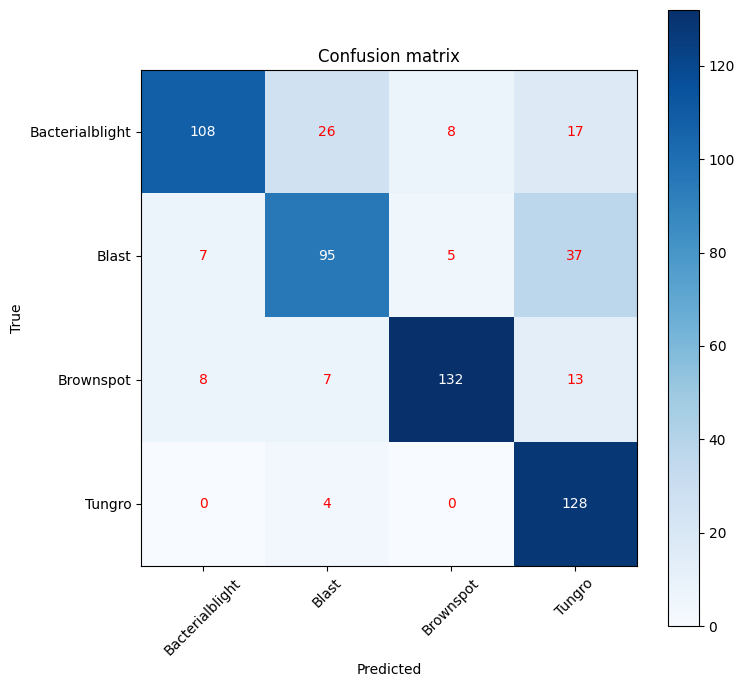

In [23]:
student = tf.keras.models.load_model(r'AlphaSelection\NewStudentAccuracy.h5')
# Clone student for later comparison
student_scratch = tf.keras.models.clone_model(student)
# Train student as done usually using data generator
student_scratch.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
student.evaluate(test_set)
student.summary()

import json

history_path = r'AlphaSelection\76_Student_history.json'
# Load the saved history
with open(history_path, 'r') as history_file:
    loaded_history = json.load(history_file)

# Access the metrics from the loaded history
print("Training Loss:", loaded_history['loss'])
print("Validation Loss:", loaded_history['val_loss'])
# Similarly, access other metrics like accuracy, etc.
print("Training Accuracy:", loaded_history['accuracy'])
print("Validation Accuracy:", loaded_history['val_accuracy'])


acc = loaded_history['accuracy']
val_acc = loaded_history['val_accuracy']

loss = loaded_history['loss']
val_loss = loaded_history['val_loss']


# Access the metrics from the loaded history
training_loss = loaded_history['loss']
validation_loss = loaded_history['val_loss']

epochs = len(acc)
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def extract_data(generator):
    data_list = []
    labels_list = []
    for _ in range(generator.__len__()):
        data, labels = generator.next()
        data_list.append(data)
        labels_list.append(labels)
    x = np.vstack(data_list)
    y = np.vstack(labels_list)
    return x, y

x_train, y_train = extract_data(train_set)
x_test, y_test = extract_data(test_set)

loss = student.evaluate(x_test,y_test)
print("Test Acc: " + str(loss[1]))
preds = student.predict(x_test)
y_pred = np.argmax(preds , axis = 1 )
label_dict = {0 : 'Bacterialblight', 1 : 'Blast', 2 : 'Brownspot', 3 : 'Tungro'}

figure = plt.figure(figsize=(28, 12))
for i, index in enumerate(np.random.choice(x_test.shape[0], size=24)):
    ax = figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_test[index]))
    predict_index = label_dict[(y_pred[index])]
    true_index = label_dict[np.argmax(y_test,axis=1)[index]]

    ax.set_title("{} ({})".format((predict_index),
                                  (true_index)),
                                  color=("green" if predict_index == true_index else "red"))
# Generate classification report
y_true = np.argmax(y_test, axis=1)
report = classification_report(y_true, y_pred)
print(report)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()

classes = list(label_dict.values())
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Print the confusion matrix values on each cell
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='red' if i != j else 'white')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



In [24]:
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=10):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature
        self.mse_metric = tf.keras.metrics.MeanSquaredError(name='mse')
        self.rmse_metric = tf.keras.metrics.RootMeanSquaredError(name='rmse')

    def call(self, inputs, training=False):
        teacher_predictions = self.teacher(inputs, training=False)
        student_predictions = self.student(inputs, training=training)
        return student_predictions

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1)
            ) * self.temperature**2
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        self.compiled_metrics.update_state(y, student_predictions)
        self.mse_metric.update_state(y, student_predictions)
        self.rmse_metric.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"loss": loss, "student_loss": student_loss, "distillation_loss": distillation_loss, "mse": self.mse_metric.result(), "rmse": self.rmse_metric.result()})
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)
        self.mse_metric.update_state(y, y_prediction)
        self.rmse_metric.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss, "mse": self.mse_metric.result(), "rmse": self.rmse_metric.result()})
        return results


# Now Finally, Distillation

In [25]:
callbacks = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0,
    patience=3,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

# Initialize and compile distiller
distiller2 = Distiller(student=student_scratch, teacher=teacher)
distiller2.compile(
    optimizer='adam',
    metrics=['accuracy'],
    student_loss_fn=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    distillation_loss_fn=tf.keras.losses.KLDivergence(),
)

# Distill teacher to student
distiller_history2 = distiller2.fit(train_set, epochs=30, validation_data=val_set, callbacks=callbacks)

# Evaluate distiller model on test dataset
distiller_results = distiller2.evaluate(test_set)
print("Distiller Model Evaluation Results:", distiller_results)



Epoch 1/30
149/149 [==============================] - 64s 417ms/step - accuracy: 0.4032 - mse: 0.1718 - rmse: 0.4145 - loss: 0.1956 - student_loss: 1.2584 - distillation_loss: 0.0776 - val_accuracy: 0.6115 - val_mse: 0.1391 - val_rmse: 0.3730 - val_student_loss: 1.0286
Epoch 2/30
149/149 [==============================] - 58s 388ms/step - accuracy: 0.6407 - mse: 0.1239 - rmse: 0.3519 - loss: 0.1387 - student_loss: 0.9130 - distillation_loss: 0.0527 - val_accuracy: 0.6723 - val_mse: 0.1104 - val_rmse: 0.3323 - val_student_loss: 0.3189
Epoch 3/30
149/149 [==============================] - 57s 381ms/step - accuracy: 0.7351 - mse: 0.0926 - rmse: 0.3043 - loss: 0.1011 - student_loss: 0.6763 - distillation_loss: 0.0372 - val_accuracy: 0.7990 - val_mse: 0.0750 - val_rmse: 0.2739 - val_student_loss: 0.4781
Epoch 4/30
149/149 [==============================] - 56s 376ms/step - accuracy: 0.7802 - mse: 0.0793 - rmse: 0.2816 - loss: 0.0859 - student_loss: 0.5826 - distillation_loss: 0.0307 - val_a

19/19 [==============================] - 1s 61ms/step - loss: 0.2748 - accuracy: 0.8891


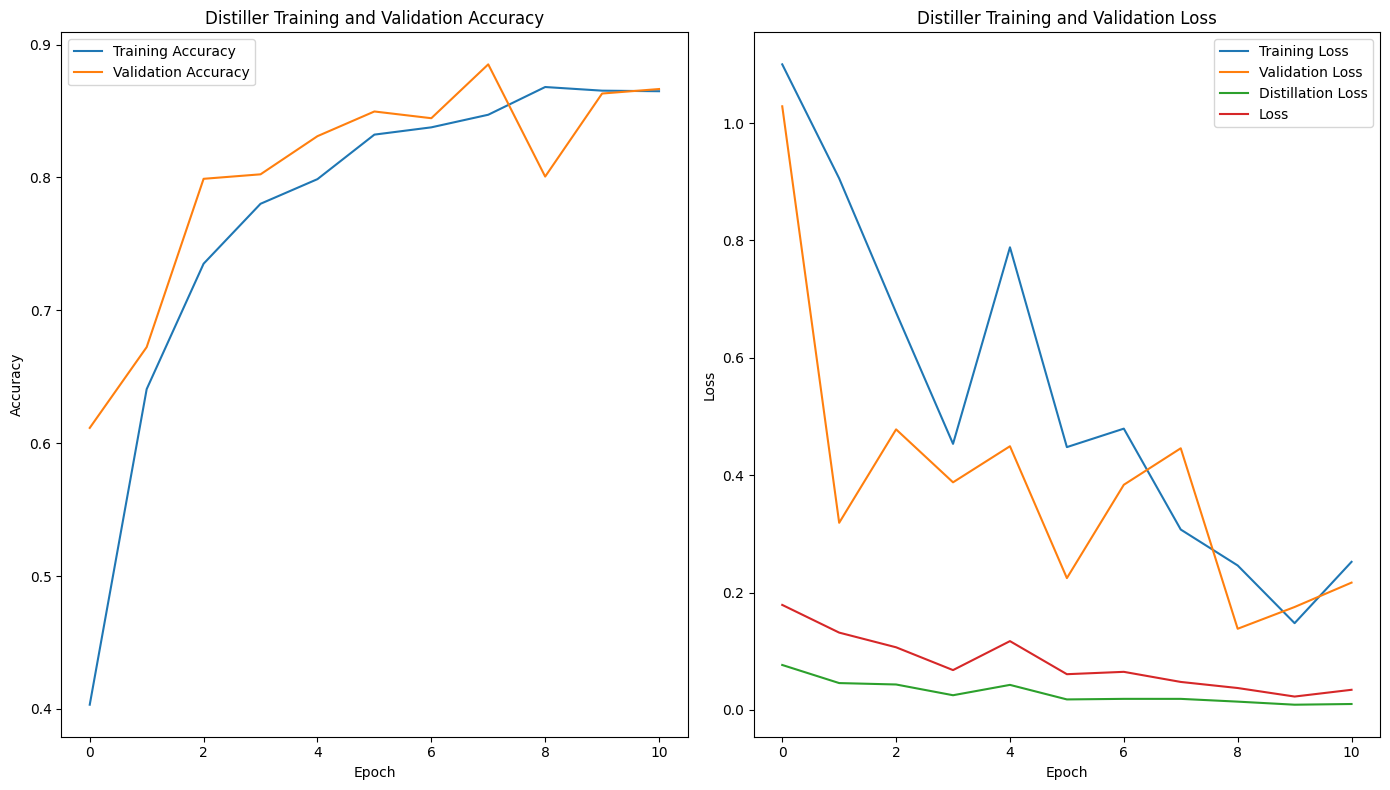

19/19 [==============================] - 1s 34ms/step
Distiller Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.94      0.85       159
           1       0.88      0.68      0.77       144
           2       0.94      0.94      0.94       160
           3       0.98      0.99      0.99       132

    accuracy                           0.89       595
   macro avg       0.90      0.89      0.89       595
weighted avg       0.89      0.89      0.89       595


Distiller Confusion Matrix:
[[150   5   3   1]
 [ 39  98   6   1]
 [  2   8 150   0]
 [  1   0   0 131]]


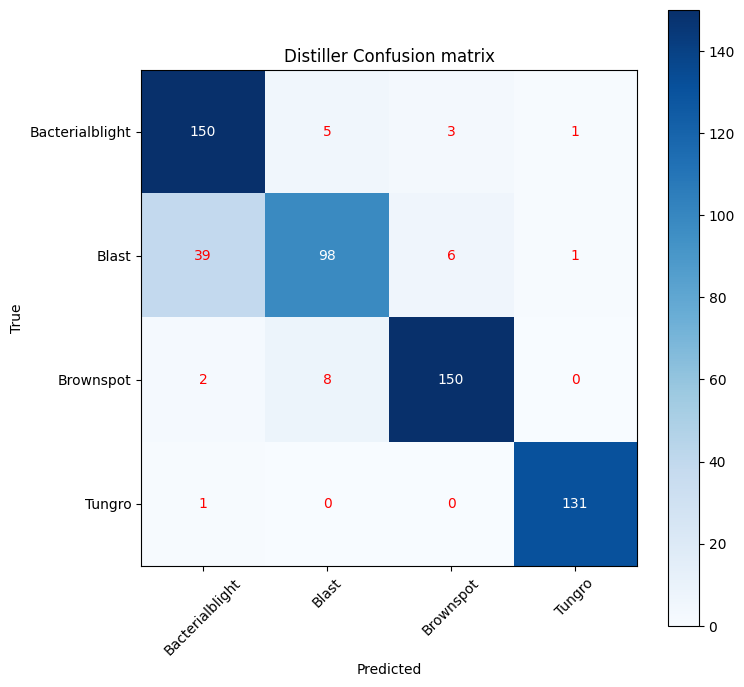

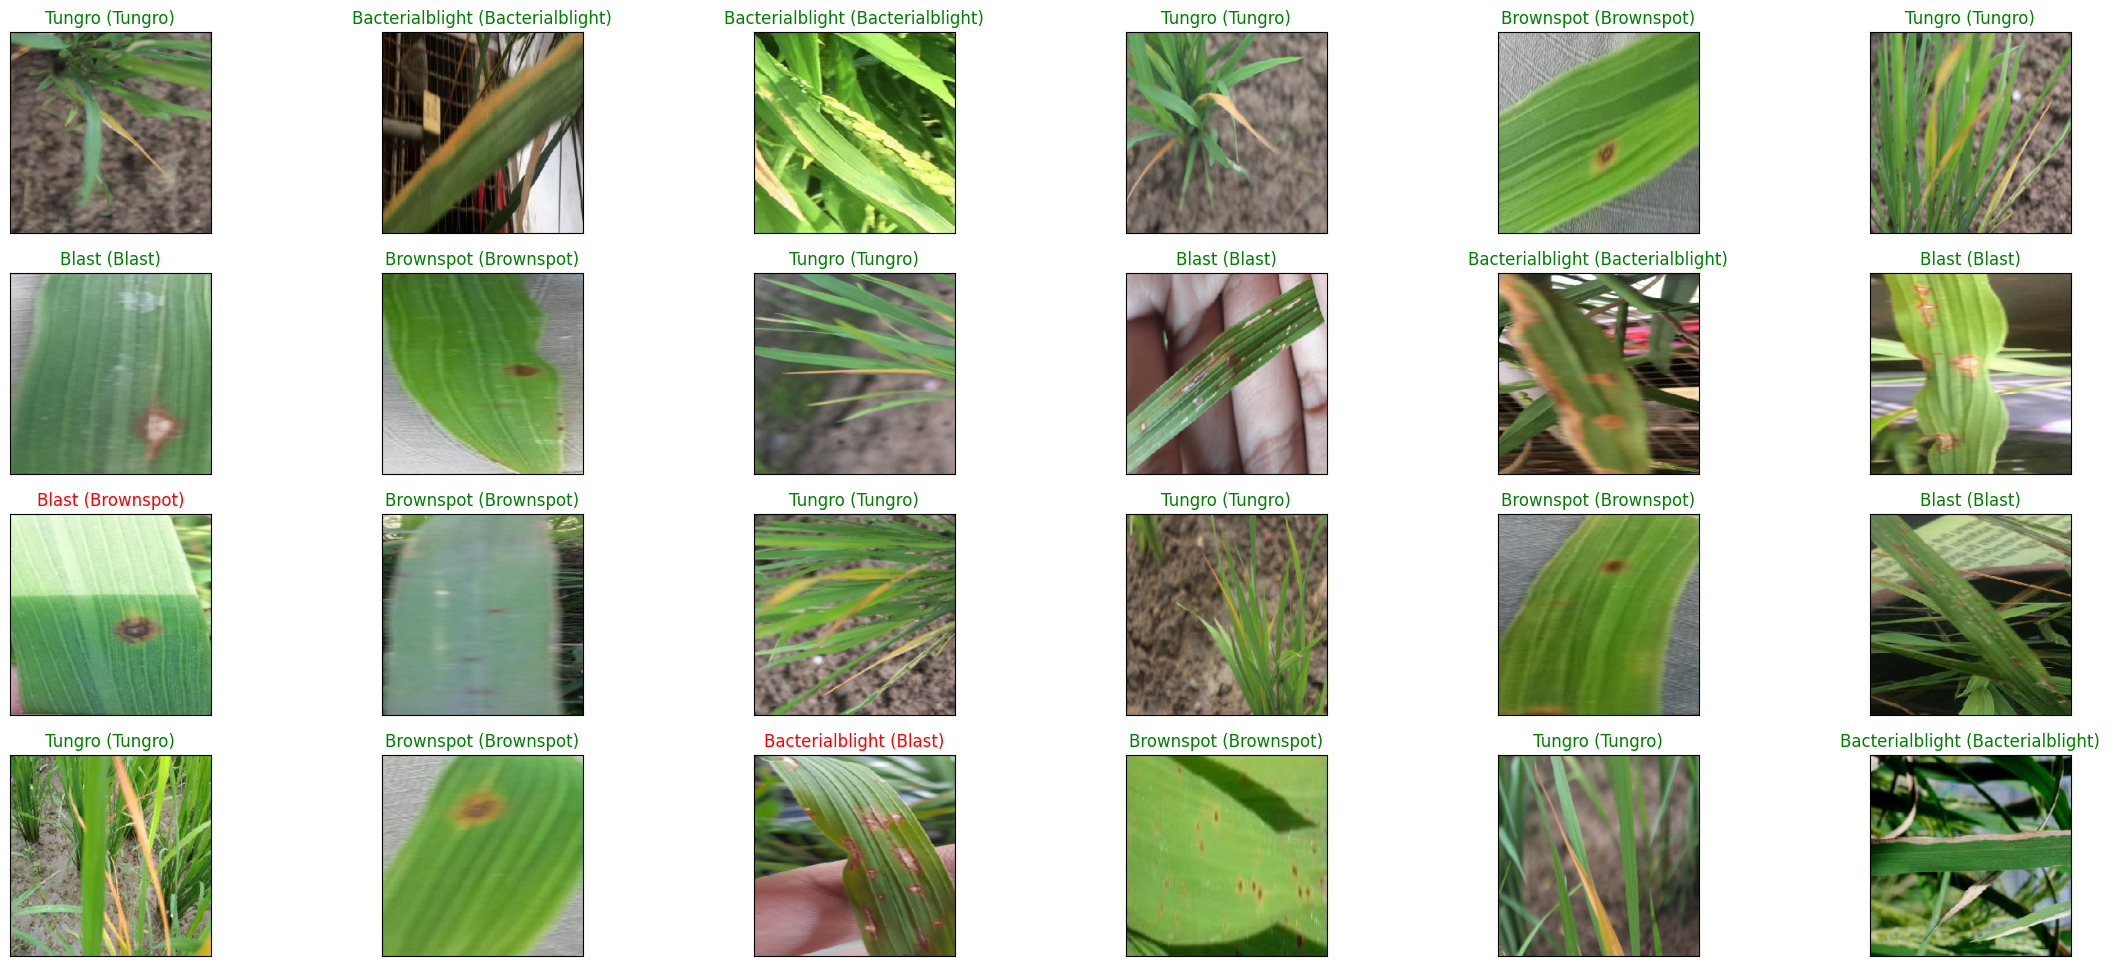

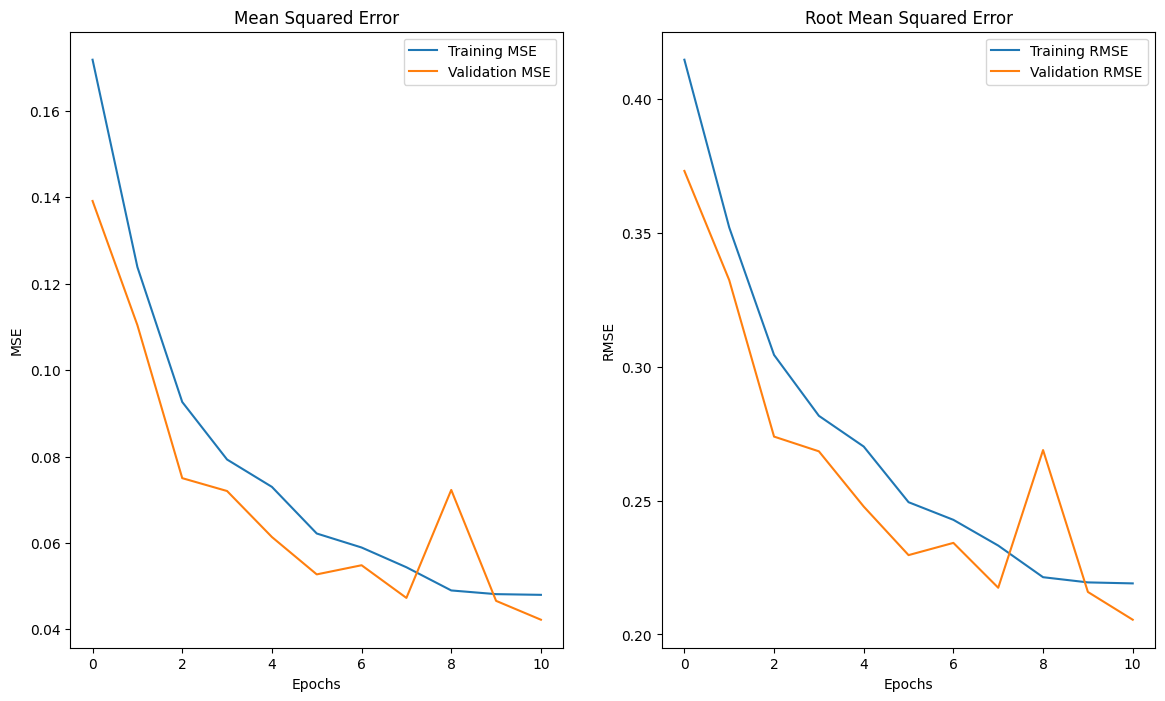

In [27]:
import matplotlib.pyplot as plt

student_scratch.evaluate(test_set)

plt.figure(figsize=(14, 8))
# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(distiller_history2.history['accuracy'], label='Training Accuracy')
plt.plot(distiller_history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Distiller Training and Validation Accuracy')

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(distiller_history2.history['student_loss'], label='Training Loss')
plt.plot(distiller_history2.history['val_student_loss'], label='Validation Loss')
plt.plot(distiller_history2.history['distillation_loss'], label='Distillation Loss')
plt.plot(distiller_history2.history['loss'], label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Distiller Training and Validation Loss')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()



import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Extract data for distiller
x_distiller, y_distiller = extract_data(test_set)


# Predictions on distiller set
distiller_predictions = distiller2.predict(x_distiller)

# Convert one-hot encoded labels to categorical labels
true_distiller_labels = np.argmax(y_distiller, axis=1)
predicted_distiller_labels = np.argmax(distiller_predictions, axis=1)

# Classification Report
print("Distiller Classification Report:")
distiller_report = classification_report(true_distiller_labels, predicted_distiller_labels)
print(distiller_report)

# Confusion Matrix
distiller_conf_matrix = confusion_matrix(true_distiller_labels, predicted_distiller_labels)
print("\nDistiller Confusion Matrix:")
print(distiller_conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 8))
plt.imshow(distiller_conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Distiller Confusion matrix')
plt.colorbar()

# Assuming label_dict is the same for the student and distiller models
classes_distiller = list(label_dict.values())
tick_marks_distiller = np.arange(len(classes_distiller))
plt.xticks(tick_marks_distiller, classes_distiller, rotation=45)
plt.yticks(tick_marks_distiller, classes_distiller)

# Print the confusion matrix values on each cell
for i in range(len(classes_distiller)):
    for j in range(len(classes_distiller)):
        plt.text(j, i, str(distiller_conf_matrix[i, j]), ha='center', va='center', color='red' if i != j else 'white')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Random predictions for the distiller model
plt.figure(figsize=(28, 12))
for i, index in enumerate(np.random.choice(x_distiller.shape[0], size=24)):
    ax = plt.subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_distiller[index]))
    predict_index = label_dict[predicted_distiller_labels[index]]
    true_index = label_dict[true_distiller_labels[index]]

    ax.set_title("{} ({})".format(predict_index, true_index),
                 color=("green" if predict_index == true_index else "red"))

# Show the random predictions
plt.show()

history = distiller_history2.history

# Extract the MSE and RMSE from the history
mse = history.get('mse')
val_mse = history.get('val_mse')
rmse = history.get('rmse')
val_rmse = history.get('val_rmse')

# Plotting MSE
plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
plt.plot(mse, label='Training MSE')
plt.plot(val_mse, label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Mean Squared Error')
plt.legend()

# Plotting RMSE
plt.subplot(1, 2, 2)
plt.plot(rmse, label='Training RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Root Mean Squared Error')
plt.legend()

plt.show()



In [28]:
student_scratch.evaluate(test_set)
student_scratch.save('CNNbasedTeacher_distil_Alpha_3.h5')

19/19 [==============================] - 1s 62ms/step - loss: 0.2748 - accuracy: 0.8891


c:\Users\My Pc\Desktop\Jisan\journal\review reponse applied soft computing\Review Progress file\R1C8\Rice-Leaf-Disease-Classification-using-Response-Based-Knowledge-Distillation\tf215_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [29]:
import json

# Evaluate student on test dataset
evaluation_results = student_scratch.evaluate(test_set)

# Save evaluation results to a JSON file
evaluation_file_path = 'CNNbasedTeacher_distil_Alpha_3.json'
with open(evaluation_file_path, 'w') as f:
    json.dump(evaluation_results, f)

19/19 [==============================] - 1s 62ms/step - loss: 0.2748 - accuracy: 0.8891
